### **Supervised & Unsupervised Learning**
### **Regression & Classification**
### **Model evaluation techniques**

Slope (m): 0.7134146341463414
Intercept (c): -0.10975609756097526


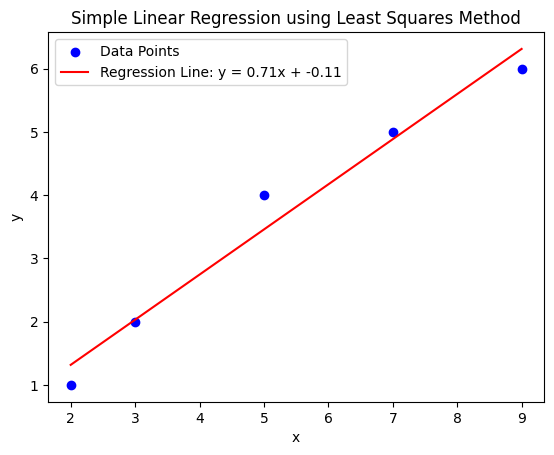

In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Given data points
x = np.array([2, 3, 5, 7, 9])
y = np.array([1, 2, 4, 5, 6])

# Number of data points
n = len(x)

# Calculate sums needed for least squares method
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x * y)
sum_x_squared = np.sum(x ** 2)

# Calculate slope (m) and intercept (c)
m = (n * sum_xy - sum_x * sum_y) / (n * sum_x_squared - sum_x ** 2)
c = (sum_y - m * sum_x) / n

# Print the calculated values of m and c
print(f"Slope (m): {m}")
print(f"Intercept (c): {c}")

# Plotting the data points
plt.scatter(x, y, color='blue', label='Data Points')

# Plotting the regression line
plt.plot(x, m * x + c, color='red', label=f'Regression Line: y = {m:.2f}x + {c:.2f}')

# Labeling the axes
plt.xlabel('x')
plt.ylabel('y')
plt.title('Simple Linear Regression using Least Squares Method')

# Adding a legend
plt.legend()

# Display the plot
plt.show()

### Compute Parmeters using Gradient Descent 

Epoch 20: Loss=0.0892, m=1.5346, c=0.4091
Epoch 40: Loss=0.0871, m=1.5453, c=0.3972
Epoch 60: Loss=0.0862, m=1.5489, c=0.3843
Epoch 80: Loss=0.0854, m=1.5523, c=0.3722
Epoch 100: Loss=0.0847, m=1.5554, c=0.3610
Epoch 120: Loss=0.0841, m=1.5583, c=0.3504
Epoch 140: Loss=0.0836, m=1.5611, c=0.3406
Epoch 160: Loss=0.0832, m=1.5636, c=0.3314
Epoch 180: Loss=0.0828, m=1.5660, c=0.3228
Epoch 200: Loss=0.0824, m=1.5682, c=0.3147


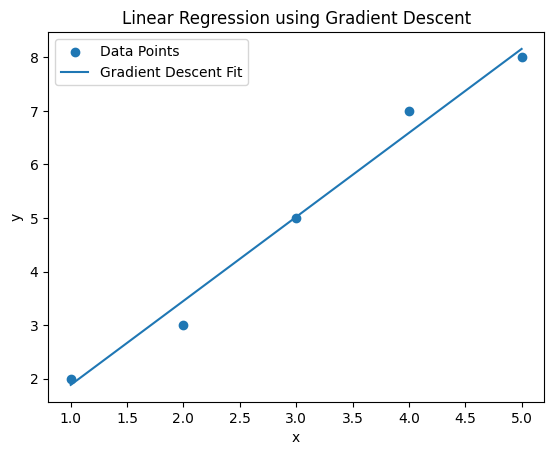

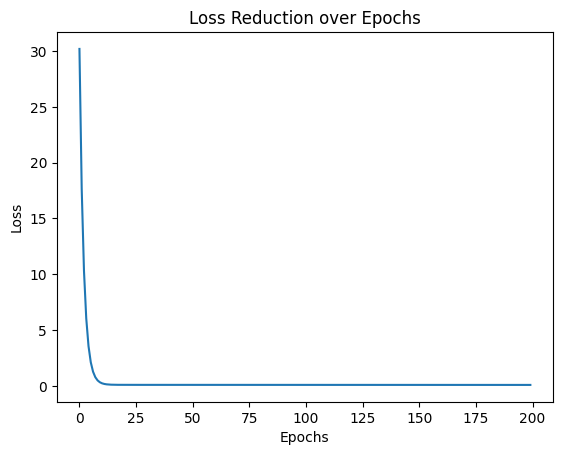

In [4]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Given data points
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 3, 5, 7, 8])

# Number of data points
n = len(x)

# Hyperparameters
learning_rate = 0.01   # slightly smaller for stability
epochs = 200

# Initialize parameters
m = 0.0
c = 0.0

# Store loss for visualization
loss_history = []

# Gradient Descent
for epoch in range(epochs):
    y_pred = m * x + c

    # Compute loss (Mean Squared Error)
    loss = np.mean((y - y_pred) ** 2)
    loss_history.append(loss)

    # Compute gradients
    dm = (-2/n) * np.sum(x * (y - y_pred))
    dc = (-2/n) * np.sum(y - y_pred)

    # Update parameters
    m = m - learning_rate * dm
    c = c - learning_rate * dc

    # Print progress
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: Loss={loss:.4f}, m={m:.4f}, c={c:.4f}")

# Plot data and regression line
plt.scatter(x, y, label="Data Points")
plt.plot(x, m * x + c, label="Gradient Descent Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression using Gradient Descent")
plt.legend()
plt.show()

# Plot loss curve
plt.plot(loss_history)
plt.title("Loss Reduction over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

### Error Metrics

In [5]:
import numpy as np

# Define a function to calculate all metrics
def calculate_metrics(y_actual, y_pred, num_predictors):
    n = len(y_actual)
    
    # Mean of actual values
    y_mean = np.mean(y_actual)
    
    # Errors
    residuals = y_actual - y_pred
    
    # Metrics
    MAE = np.mean(np.abs(residuals))
    SSE = np.sum(residuals**2)
    MSE = np.mean(residuals**2)
    RMSE = np.sqrt(MSE)
    MAPE = np.mean(np.abs(residuals / y_actual)) * 100
    
    # R-squared
    SS_total = np.sum((y_actual - y_mean)**2)
    R_square = 1 - (SSE / SS_total)
    
    # Adjusted R-squared
    Adjusted_R_square = 1 - ((SSE / (n - num_predictors - 1)) / (SS_total / (n - 1)))
    
    # Print all metrics
    print(f"Mean Absolute Error (MAE): {MAE}")
    print(f"Sum of Squared Errors (SSE): {SSE}")
    print(f"Mean Squared Error (MSE): {MSE}")
    print(f"Root Mean Squared Error (RMSE): {RMSE}")
    print(f"Mean Absolute Percentage Error (MAPE): {MAPE}%")
    print(f"R-squared: {R_square}")
    print(f"Adjusted R-squared: {Adjusted_R_square}")

# Example usage:
y_actual = np.array([3, 4, 5, 6])
y_pred = np.array([2.5, 4.2, 4.8, 6.3])

# Assuming 1 predictor (simple linear regression)
num_predictors = 1

calculate_metrics(y_actual, y_pred, num_predictors)

Mean Absolute Error (MAE): 0.30000000000000004
Sum of Squared Errors (SSE): 0.4200000000000001
Mean Squared Error (MSE): 0.10500000000000002
Root Mean Squared Error (RMSE): 0.32403703492039304
Mean Absolute Percentage Error (MAPE): 7.666666666666668%
R-squared: 0.9159999999999999
Adjusted R-squared: 0.874


### Multiple Linear Regression

Coefficients (Intercept, b1, b2): [-0.5 -1.   3. ]
Predicted values: [ 1.5  6.5  8.5 13.5]
SSE: 1.0
MSE: 0.25
RMSE: 0.5
MAE: 0.5
R^2: 0.9866666666666667
Adjusted R^2: 0.9600000000000001


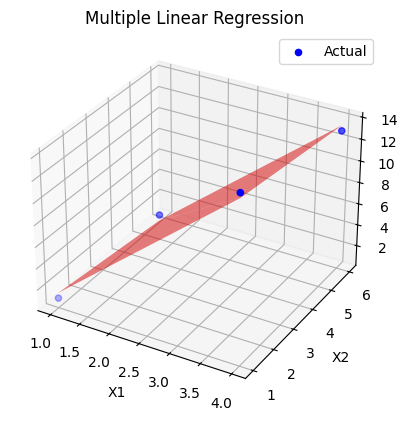

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Function to calculate coefficients using Least Squares Method
def least_squares(X, y):
    # Adding a column of ones for the intercept term (bias)
    X_b = np.c_[np.ones((X.shape[0], 1)), X]  # Adding bias term
    # Using the normal equation: beta = (X^T * X)^(-1) * X^T * y
    beta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    return beta

# Function to predict y values based on the model coefficients
def predict(X, beta):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]  # Adding bias term for predictions
    return X_b.dot(beta)

# Function to calculate error metrics
def calculate_error_metrics(y, y_pred, X):
    residuals = y - y_pred
    SSE = np.sum(residuals ** 2)
    MSE = SSE / len(y)
    RMSE = np.sqrt(MSE)
    MAE = np.mean(np.abs(residuals))
    R2 = 1 - (SSE / np.sum((y - np.mean(y)) ** 2))
    R2_adj = 1 - (1 - R2) * (len(y) - 1) / (len(y) - X.shape[1] - 1)
    
    print(f"SSE: {SSE}")
    print(f"MSE: {MSE}")
    print(f"RMSE: {RMSE}")
    print(f"MAE: {MAE}")
    print(f"R^2: {R2}")
    print(f"Adjusted R^2: {R2_adj}")

# Sample data with 2 features (X1, X2) and target variable (y)
X = np.array([[1, 1], 
              [2, 3], 
              [3, 4], 
              [4, 6]])

y = np.array([1, 7, 9, 13])

# Solve for coefficients using least squares
beta = least_squares(X, y)
print(f"Coefficients (Intercept, b1, b2): {beta}")

# Predict the target values
y_pred = predict(X, beta)
print(f"Predicted values: {y_pred}")

# Calculate error metrics
calculate_error_metrics(y, y_pred, X)

# Plotting the results
fig = plt.figure()

# For 2D input, we can use 3D plotting
if X.shape[1] == 2:
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], y, color='blue', label='Actual')
    ax.plot_trisurf(X[:, 0], X[:, 1], y_pred, color='red', alpha=0.5)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    plt.title('Multiple Linear Regression')
    plt.legend()
    plt.show()

#### Variance Inflation Factor to detect Multicollinearity

In [9]:
import statsmodels.api as sm
import pandas as pd

# Create sample data
data = {'X1': [1, 2, 3, 4],
        'X2': [100, 7, 4000, 5.1],
        'X3': [2.1, -4.1, 42, 5]}

df = pd.DataFrame(data)

# Regress X1 on X2 and X3
X = df[['X2', 'X3']]
X = sm.add_constant(X)  # Add intercept
y = df['X1']

# Fit the model
model = sm.OLS(y, X).fit()

# Get R^2 (R_i^2 for X1)
R1_squared = model.rsquared
print("R_1^2 for X1:", R1_squared)
VIF = 1/(1-R1_squared)
print("VIF for X1:", VIF)

R_1^2 for X1: 0.3802000152040288
VIF for X1: 1.6134237246378522


 #### Correlation Matrix to detect Multicollinearity

Correlation Matrix:
          X1        X2        X3
X1  1.000000  0.241567  0.339337
X2  0.241567  1.000000  0.983806
X3  0.339337  0.983806  1.000000


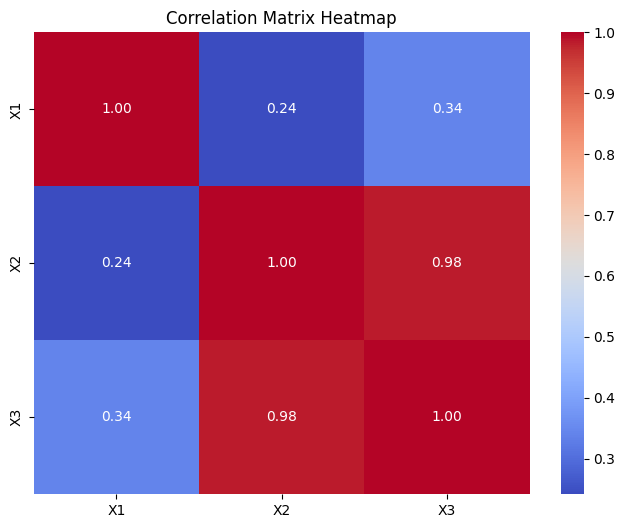

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create sample data
data = {'X1': [1, 2, 3, 4],
        'X2': [100, 7, 4000, 5.1],
        'X3': [2.1, -4.1, 42, 5]}

df = pd.DataFrame(data)

# Calculate the correlation matrix
corr_matrix = df.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(corr_matrix)

# Plot a heatmap for the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

#### Compute Paramters using Gradient Descent method

Optimal Coefficients: [-0.50105015 -0.99708025  2.99821066]
Cost after final iteration: 0.1250000821510015


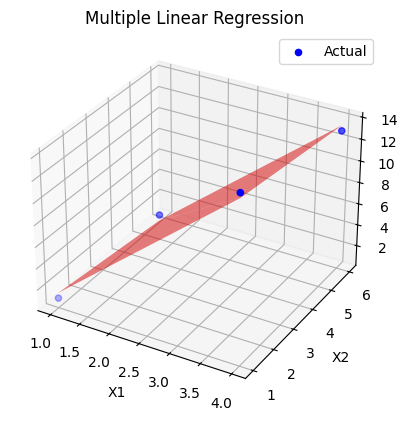

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Function to compute the cost (MSE)
def compute_cost(X, y, w):
    n = len(y)
    predictions = X.dot(w)
    cost = (1 / (2 * n)) * np.sum((predictions - y) ** 2)
    return cost

# Gradient Descent function
def gradient_descent(X, y, alpha, iterations):
    # Adding a column of ones for the intercept term (bias)
    X = np.c_[np.ones((X.shape[0], 1)), X]
    
    w = np.zeros(X.shape[1])
    n = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        predictions = X.dot(w)
        errors = predictions - y
        gradient = X.T.dot(errors) / n
        w = w - alpha * gradient
        cost_history[it] = compute_cost(X, y, w)

    return w, cost_history

# Sample data (n=4, 2 features)
X = np.array([[1, 1],
              [2, 3],
              [3, 4],
              [4, 6]])  # Add a column of ones for the intercept term
y = np.array([1, 7, 9, 13])

# Initialize parameters
w = np.zeros(X.shape[1])
alpha = 0.05  # Learning rate
iterations = 10000

# Perform gradient descent
w_optimal, cost_history = gradient_descent(X, y, alpha, iterations)

print(f"Optimal Coefficients: {w_optimal}")
print(f"Cost after final iteration: {cost_history[-1]}")

# Plotting the results
fig = plt.figure()

# For 2D input, we can use 3D plotting
if X.shape[1] == 2:
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], y, color='blue', label='Actual')
    ax.plot_trisurf(X[:, 0], X[:, 1], y_pred, color='red', alpha=0.5)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    plt.title('Multiple Linear Regression')
    plt.legend()
    plt.show()

### Polynomial Regression
#### Single Variable Polynomial Regression

Intercept: 1.7999999999999936
Coefficients: [ 0.         -1.05714286  1.14285714]
Mean Squared Error (MSE): 0.022857142857142826
R-squared: 0.9996778869383154


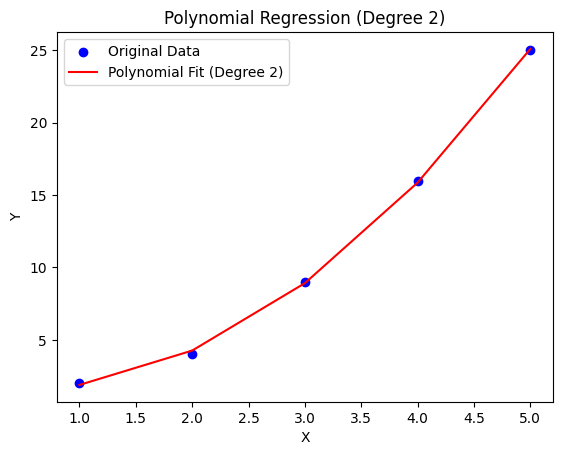

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Sample data: x and y values
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([2, 4, 9, 16, 25])

# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Fit the polynomial regression model
model = LinearRegression()
model.fit(X_poly, y)

# Predict y values based on the model
y_pred = model.predict(X_poly)

# Calculate error metrics
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

# Print the coefficients
print(f"Intercept: {model.intercept_}")
print(f"Coefficients: {model.coef_}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared: {r2}")

# Plot the original data and the polynomial fit
plt.scatter(X, y, color='blue', label='Original Data')
plt.plot(X, y_pred, color='red', label='Polynomial Fit (Degree 2)')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Polynomial Regression (Degree 2)')
plt.legend()
plt.show()

#### Multivariate Polynomial Regression

Intercept: 6.85238095238096
Coefficients: [-6.77236045e-15  4.50000000e-01  4.50000000e-01 -4.02380952e-01
  4.76190476e-02  4.97619048e-01]


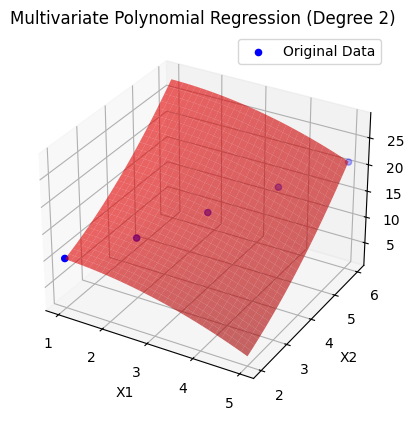

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# Sample data (two features: x1, x2)
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6]])
y = np.array([10, 12, 15, 18, 21])

# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Fit the polynomial regression model
model = LinearRegression()
model.fit(X_poly, y)

# Predict y values based on the model
y_pred = model.predict(X_poly)

# Print the coefficients
print(f"Intercept: {model.intercept_}")
print(f"Coefficients: {model.coef_}")

# Plotting the data and polynomial fit (3D plot)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for the actual data points
ax.scatter(X[:, 0], X[:, 1], y, color='blue', label='Original Data')

# Surface plot for the polynomial fit (meshgrid for smooth plotting)
x1_grid, x2_grid = np.meshgrid(np.linspace(1, 5, 30), np.linspace(2, 6, 30))
X_grid = np.column_stack([x1_grid.ravel(), x2_grid.ravel()])
X_grid_poly = poly.transform(X_grid)
y_grid_pred = model.predict(X_grid_poly)

# Reshape predictions for surface plot
y_grid_pred = y_grid_pred.reshape(x1_grid.shape)

# Surface plot for the polynomial fit
ax.plot_surface(x1_grid, x2_grid, y_grid_pred, color='red', alpha=0.6)

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Y')
ax.set_title('Multivariate Polynomial Regression (Degree 2)')

plt.legend()
plt.show()